# **TAS (Tele Assistance System) Dimensional Analysis Modelling**
NOTE: _[DASA CASE STUDY 1]_

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Simulating the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for Software Architecture (DASA) methodology, its software tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

---

_**NOTE: MORE DETAILS ON THE ARCHITECTURE IN THE ANALYTICAL MODELLING NOTEBOOK!.**_

---

## **Code**

_**SUMMARY:**_

This code is for the analytical solution of the Case Study (TAS) Dimensional Analysis Model and is structured as follows:
1. Analytical Dimensional Model (DA).
2. Importing necessary libraries and modules.
3. Loading DA default configuration.
4. Solving the DA analytically.
5. Solving the DA with Monte Carlo simulations.
6. Plotting the DA with the obtained metrics.
7. Loading DA 'optimal' configuration.
8. Solving the DA optimally.
9. Simulating the DA with the 'optimal' configuration.
10. Plotting the optimal DA with the obtained metrics.
11. Saving the results.
12. Comparing the analytical results (Default Vs. Optimal)
13. Visualizing the results.
14. Generating a summary report.

## **Target System Queue Network Model**

<svg viewBox="0 0 4650 2000" width="1400" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/04A - Queue Network.svg" alt="queue-net-diagram" />
    <div align="center"><em>Image 4. TAS Queue Network Diagram.</em></div>
</svg>

### **Necessary Imports**

In [2]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time
from typing import Union

# Third-party imports
import numpy as np
import pandas as pd

# import qimensional model libraries PyDASA
# config module
from pydasa.utils import config
# FDU modules
from pydasa.core.fundamental import Dimension
# FDU regex management
from pydasa.dimensional.framework import DimScheme
# Variable and Variable modules
from pydasa.core.parameter import Variable
# Dimensional Matrix Modelling module
from pydasa.dimensional.model import DimMatrix
# sensitivity analysis modules
from pydasa.analysis.scenario import DimSensitivity
from pydasa.handlers.influence import SensitivityHandler
# Monte Carlo Simulation modules
from pydasa.analysis.simulation import MonteCarloSim
from pydasa.handlers.practical import MonteCarloHandler

# import queue network + models packages
from src.model.queueing import Queue
from src.model.analytical import solve_jackson_network, calculate_net_metrics

# import plot functions + grahics
from src.view.plots import plot_queue_network
from src.view.plots import plot_net_comparison
from src.view.plots import plot_net_difference
from src.view.plots import plot_nodes_heatmap
from src.view.plots import plot_nodes_diffmap
from src.view.plots import plot_performance_coef_chart

### **Function Definitions**

In [3]:
# Simple formatter for console output

def fmt(val: Union[int, float, np.number]) -> Union[str, np.ndarray]:
    """Format a number to 4 decimal places for console output.

    Args:
        val (Union[int, float, np.number, np.ndarray]): The value to format.

    Returns:
        Union[str, np.ndarray]: The formatted value as a string or an array of strings.
    """
    if isinstance(val, (int, float, np.number)):
        if np.isnan(val) or np.isinf(val):
            return str(val)
        return f"{val:.4f}"
    elif isinstance(val, np.ndarray):
        return np.array([fmt(x) for x in val])
    return val

In [4]:
# Load configuration from a CSV file
def load(path: str, fname: str) -> pd.DataFrame:
    """Load configuration from a CSV file.

    Args:
        path (str): The directory path where the CSV file is located.
        fname (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: A DataFrame containing the configuration data.
            CSV format:
                - node: <node_id>
                - miu: <mean_service_time>
                - c: <service_channels>
                - K: <buffer_capacity | max_queue_length>
                - lambda0: <initial_arrival_rate>
                - L0: <initial_queue_length>
                - pm: <matrix_routing_probabilities>
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Loading configuration from: {_file_path}")
    df = pd.read_csv(_file_path)
    return df

In [5]:
# save dataframes in CSV files
def save(path: str, fname: str, data: pd.DataFrame) -> None:
    """Save a DataFrame to a CSV file.

    Args:
        path (str): The directory path where the CSV file will be saved.
        fname (str): The name of the CSV file to save.
        data (pd.DataFrame): The DataFrame containing the data to save.
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Saving data to: {_file_path}")
    data.to_csv(_file_path, index=False)

In [6]:
# calculate queue length, with ququeing theory formulas
def queue_length(lambda_z: float,
                 mu: float,
                 c: int,
                 K: int) -> float:
    """Calculate the average queue length (Lq) for an M/M/c/K queueing system.

    Args:
        lambda_z (float): The arrival rate (λ).
        mu (float): The service rate (μ).
        c (int): The number of service channels.
        K (int): The maximum number of customers in the system.

    Returns:
        float: The average number of requests in the system (L, Lq).
    """
    if lambda_z > mu * c:
        lambda_z = mu * 0.9999  # to avoid unstable system
    q = Queue("M/M/s/K", lambda_z, mu, c, K)
    q.calculate_metrics()
    len_queue = q.avg_len
    return len_queue

In [7]:
# calculate queue time, with Little's Law
def queue_time(lambda_z: float, len_queue: float) -> float:
    """Calculate the average time in the queue system (W, Wq).

    Args:
        len_queue (float): The average queue length (L, Lq).
        lambda_z (float): The arrival rate (λ).

    Returns:
        float: The average wait time in the queue (W, Wq).
    """
    if lambda_z == 0:
        return float("inf")  # Avoid division by zero
    wait_time = len_queue / lambda_z
    return wait_time

In [8]:
def adjust_rate(rate:float, err:float=0.0) -> float:
    """Adjust the arrival rate by a given error percentage.

    Args:
        rate (float): The original arrival rate (λ).
        err (float): The error percentage to adjust the rate by.

    Returns:
        float: The adjusted arrival rate otherwise known as departure rate (x).
    """
    adjusted_rate = rate * (1 - err)
    return adjusted_rate

In [9]:
def uniform_int(low: int, high: int) -> int:
    """Generate a random integer within a specified range.

    Args:
        low (int): The lower bound of the range (inclusive).
        high (int): The upper bound of the range (exclusive).

    Returns:
        int: A random integer between low and high.
    """
    return np.random.randint(low, high)

In [10]:
def shifted_uniform_int(low: int, high: int, shift: int) -> int:
    """Generate a random integer within a specified range and apply a shift.

    Args:
        low (int): The lower bound of the range (inclusive).
        high (int): The upper bound of the range (exclusive).
        shift (int): The value to shift the generated number by.

    Returns:
        int: A random integer between low and high, shifted by the specified amount.
    """
    return np.random.randint(low, high) + shift

In [11]:
def uniform(low: float, high: float) -> float:
    """Generate a random float within a specified range.

    Args:
        low (float): The lower bound of the range (inclusive).
        high (float): The upper bound of the range (exclusive).

    Returns:
        float: A random float between low and high.
    """
    return np.random.uniform(low, high)

In [12]:
# path = os.path.dirname(__file__)\
PATH = os.getcwd()
print(f"Notebook path: {PATH}")

Notebook path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies


In [13]:
# Folder names
asset_folder = "assets"
docs_folder = "docs"
img_folder = "img"
data_folder = "data"
report_folder = "reports"
results_folder = "results"
cs_folder = "cs1"

In [14]:
# setting case study data folder
file_path = os.path.join(PATH, data_folder, cs_folder)
print(f"Data path: {file_path}")

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\cs1


### **Queue Model**
#### **Creating Dimensionless Charts**

##### **FDUs (Fundamental Design Units)**

In [15]:
# setting up custom FDU for software architecture
tas_fwk = "SOFTWARE"
tas_scm = DimScheme(_sym="FDU_{TAS}",
                    _alias="fdu_tas",
                    _idx=0,
                    name="TAS FDUs",
                    _fwk=tas_fwk,
                    description="FDU schema for the TAS case study.")
# print(tas_scm)
print("=== TAS Fundamental Dimenional Unit (FDU) Schema ===")
for dim in tas_scm.fdus:
    print(f"\t'{dim.sym}': {dim.name}, [{dim.unit}]")

=== TAS Fundamental Dimenional Unit (FDU) Schema ===
	'T': Time, [s]
	'D': Data, [bit]
	'E': Effort, [req]
	'C': Connectivity, [node]
	'A': Capacity, [process]


In [16]:
tas_fwk = "CUSTOM"
fdu_lt = [
    {
        "_idx": 0,
        "_sym": "T",
        "_fwk": tas_fwk,
        "description": "Duration of an event or interval.",
        "_unit": "s",
        "name": "Time",
        },
    {
        "_idx": 1,
        "_sym": "I",
        "_fwk": tas_fwk,
        "description": "Computational unit to process/handle or store requests.",
        "_unit": "req",
        "name": "Item",
        },
    {
        "_idx": 2,
        "_sym": "D",
        "_fwk": tas_fwk,
        "description": "Information processed by a component.",
        "_unit": "bit",
        "name": "Data",
    },
]
tas_scm = DimScheme(_sym="FDU_{Custom TAS}",
                    _alias="fdu_custom_tas",
                    _idx=0,
                    name="Custom TAS FDUs",
                    _fdus=fdu_lt,
                    _fwk=tas_fwk,
                    description="Minimal FDU schema for TAS case study.")

# print(tas_scm)
print("=== TAS Fundamental Dimensional Unit (FDU) Schema ===")
for dim in tas_scm.fdus:
    print(f"\t'{dim.sym}': {dim.name}, [{dim.unit}]")

=== TAS Fundamental Dimensional Unit (FDU) Schema ===
	'T': Time, [s]
	'I': Item, [req]
	'D': Data, [bit]


In [17]:
tas_scm.update_global_config()
print("---- Checking Schema Regex ----")
print("\tWKNG_DFLT_FDU_PREC_LT:", config.WKNG_FDU_PREC_LT)
print("\tWKNG_FDU_RE:", config.WKNG_FDU_RE)
print("\tWKNG_POW_RE:", config.WKNG_POW_RE)
print("\tWKNG_NO_POW_RE:", config.WKNG_NO_POW_RE)
print("\tWKNG_FDU_SYM_RE:", config.WKNG_FDU_SYM_RE)

---- Checking Schema Regex ----
	WKNG_DFLT_FDU_PREC_LT: ['T', 'I', 'D']
	WKNG_FDU_RE: ^[TID](\^-?\d+)?(\*[TID](?:\^-?\d+)?)*$
	WKNG_POW_RE: \-?\d+
	WKNG_NO_POW_RE: [TID](?!\^)
	WKNG_FDU_SYM_RE: [TID]


In [ ]:
print("---- Config Sensitivty & Monte Carlo Samples ----")
n_sens = 10000
n_exp = 10000
print(f"\tSensitivity Analysis Samples: {n_sens}")
print(f"\tMonte Carlo Simulation Samples: {n_exp}")

---- Config Sensitivty & Monte Carlo Samples ----
	Sensitivity Analysis Samples: 1000
	Monte Carlo Simulation Samples: 30000


##### **Base Configuration**

In [19]:
# Load configuration with mixed queue models
dflt_qn_cfg = load(file_path, "default_qn_model.csv")
print("Queue Network Configuration:")
dflt_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\cs1\default_qn_model.csv
Queue Network Configuration:


,node,name,type,miu,s,K,lambda0,L0,pm
0,1,TAS 1(1)*,M/M/1/K,900.0,1,1000,345.0,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2(1)*,M/M/1/K,700.0,1,1000,0.0,0,"[0.00,0.00,0.00,0.33,0.33,0.33,0.00,0.00,0.00,..."
2,3,TAS 3(1)*,M/M/1/K,700.0,1,1000,0.0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.33,0.33,..."
3,4,MAS 1,M/M/1/K,180.0,1,1000,0.0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/1/K,530.0,1,1000,0.0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [20]:
# Load configuration with mixed queue models
dflt_da_cfg = load(file_path, "default_dim_variables.csv")
print("Dimension Variables Configuration:")
dflt_da_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\cs1\default_dim_variables.csv
Dimension Variables Configuration:


,_idx,dm,_sym,_alias,_fwk,name,description,relevant,_cat,_dims,...,_min,_max,_mean,_std_units,_std_min,_std_max,_std_mean,_dist_type,_depends,_dist_params
0,1,1,\lambda_{1},lambda_tas_1,CUSTOM,TAS 1 arrival rate,Arrival rate for TAS 1,True,IN,I*T^-1,...,0.1,345,172.55,req/s,0.1,345.0,172.55,uniform,[],"{'low': 0.1, 'high': 345}"
1,2,1,\mu_{1},mu_tas_1,CUSTOM,TAS 1 service rate,Service rate for TAS 1,True,CTRL,I*T^-1,...,0.1,900,450.05,req/s,0.1,900.0,450.05,uniform,[],"{'low': 0.1, 'high': 900}"
2,3,1,err_{1},err_tas_1,CUSTOM,TAS 1 error probability,Service error probability for TAS 1,False,CTRL,I*T^-1,...,0.00%,0.00%,0,n.a.,0.0,0.0,0.00,constant,[],{'constant': 0}
3,4,1,\chi_{1},chi_tas_1,CUSTOM,TAS 1 departure rate,Departure rate for TAS 1,True,CTRL,I*T^-1,...,0.1,345,172.55,req/s,0.1,345.0,172.55,adjusted_rate,"['\mu_{1}' , 'err_{1}']",{}
4,5,1,c_{1},c_tas_1,CUSTOM,TAS 1 resourses,Number of resources allocated in TAS 1,True,IN,I,...,1,2,1.5,req,1.0,2.0,1.50,uniform_int,[],"{'low': 1, 'high': 2}"


###### **Loading Dimensional Variables**

In [21]:
print("---- Dimensional Variables by Dimensional Matrix ----")
# create a dimensional set of variables from config file
# unique dimensional matrix
dflt_dim_relevance_lt = dflt_da_cfg["dm"].unique().tolist()
# dictionary to hold dimensional variables
dflt_dim_var_groups = {}

# group by dimensional matrix
for dm in dflt_dim_relevance_lt:
    # filter by dimensional matrix number
    _vars = dflt_da_cfg[dflt_da_cfg["dm"] == dm]
    # filter by relevant attributes
    _vars = _vars[_vars["dm"] == dm]
    print(f"Dimensional Matrix: {dm}, with {_vars.shape[0]} relevant vars.")
    tdict = {}
    for var in _vars.to_dict(orient="records"):
        key = var["_sym"]
        # remove unnecessary keys
        var.pop("dm", None)
        # cast internal dict column
        if var.get("_dist_params") != None:
            data = eval(var.get("_dist_params"))
            dt = {"_dist_params": data}
            # print(data, type(data))
            var.update(dt)
        if var.get("_depends") != None:
            data = eval(var.get("_depends"))
            dt = {"_depends": data}
            # print(data, type(data))
            var.update(dt)
        # create variable instance
        tdict[key] = Variable(**var)
        # print(f"\tCreated Variable Instance: {key}: {tdict[key]}")
    # add to dictionary
    dflt_dim_var_groups[dm] = tdict

print(f"No. of Dimensional Variables Groups: {len(dflt_dim_var_groups)}")

---- Dimensional Variables by Dimensional Matrix ----
Dimensional Matrix: 1, with 11 relevant vars.
Dimensional Matrix: 2, with 11 relevant vars.
Dimensional Matrix: 3, with 11 relevant vars.
Dimensional Matrix: 4, with 11 relevant vars.
Dimensional Matrix: 5, with 11 relevant vars.
Dimensional Matrix: 6, with 11 relevant vars.
Dimensional Matrix: 7, with 11 relevant vars.
Dimensional Matrix: 8, with 11 relevant vars.
Dimensional Matrix: 9, with 11 relevant vars.
Dimensional Matrix: 10, with 11 relevant vars.
Dimensional Matrix: 11, with 11 relevant vars.
Dimensional Matrix: 12, with 11 relevant vars.
Dimensional Matrix: 13, with 11 relevant vars.
No. of Dimensional Variables Groups: 13


In [22]:
print("---- Configure Simulation Distribution Function for Variables ----")
# im tired so lambda functions are in order
for dm in dflt_dim_var_groups:
    for key, var in dflt_dim_var_groups[dm].items():
        # print(var)
        # if the dist is uniform for discrete vals like c's and K's
        if var._dist_type == "uniform_int":
            _min = var._dist_params.get("low")  # Default if missing
            _max = var._dist_params.get("high")  # Default if missing
            # Use default parameter capture to correctly bind values
            var._dist_func = lambda l=_min, h=_max: np.random.randint(l, h)
            # print(f"var sym: {var._sym}, min: {_min}, max: {_max}")

        # if the dist is shifted uniform for discrete vals like c's + K's
        if var._dist_type == "shifted_uniform_int":
            _min = var._dist_params.get("low")
            _max = var._dist_params.get("high")
            var._dist_func = lambda b, l=_min, h=_max: b + np.random.randint(l,
                                                                             h)
            
        # if the dist is uniform for continuous vals like miu's and lambda's
        if var._dist_type == "uniform":
            _low = var._dist_params.get("low")
            _high = var._dist_params.get("high")
            var._dist_func = lambda l=_low, h=_high: np.random.uniform(l, h)
            # print(f"var sym: {var._sym}, low: {_low}, high: {_high}")

        # with exponential distribution
        if var._dist_type == "exponential":
            _scale = var._dist_params.get("scale")
            var._dist_func = lambda s=_scale:  np.random.exponential(s)

        # if the dist is constant, like the error in the queue model
        if var._dist_type == "constant":
            _constant = var._dist_params.get("constant")
            var._dist_func = lambda cst=_constant: cst

        # if the dist is adjusted uniform for continous vals like chi's = lambda's * (1 - x%)
        if var._dist_type == "adjusted_rate":
            var._dist_func = lambda rate, err: adjust_rate(rate, err)
            # var._dist_func =  adjust_rate

        # if the dist is a queue theory formula
        if var._dist_type == "queue_length":
            # var._dist_func = queue_length
            var._dist_func = lambda la_z, mu, c, K: queue_length(la_z, mu, c, K)

        if var._dist_type == "queue_time":
            # var._dist_func = queue_time
            var._dist_func = lambda La_z, lq: queue_time(La_z, lq)

---- Configure Simulation Distribution Function for Variables ----


###### **Creating Dimensional Model**

In [24]:
print("---- Creating Dimensional Model (Matrix) ----")
dflt_dim_model_groups = {}

# group by dimensional matrix
for dm in dflt_dim_relevance_lt:
    tas_vars = dflt_dim_var_groups[dm]
    print(f"Dimensional Matrix ID: {dm}, N Variables: {len(tas_vars)}")
    dflt_dim_model_groups[dm] = DimMatrix(_fwk="CUSTOM",
                                          _idx=dm,
                                          _framework=tas_scm)
    # setting Dimensional Model variables
    dflt_dim_model_groups[dm].variables = tas_vars
    _msg = "\tSetting parameters for the DA, "
    _msg += f"N Variables: {len(dflt_dim_model_groups[dm].variables)}. "
    # _msg += f"Variables: {dflt_dim_model_groups[dm].variables.keys()}"
    print(_msg)

    # setting Dimensional Model relevance list
    dflt_dim_model_groups[dm].relevant_lt = tas_vars
    _msg = "\tSetting the relevance list for the DA, "
    _msg += f"N Variables: {len(dflt_dim_model_groups[dm].relevant_lt)}. "
    # _msg += f"Variables: {dflt_dim_model_groups[dm].relevant_lt.keys()}"
    print(_msg)


---- Creating Dimensional Model (Matrix) ----
Dimensional Matrix ID: 1, N Variables: 11
	Setting parameters for the DA, N Variables: 11. 
	Setting the relevance list for the DA, N Variables: 8. 
Dimensional Matrix ID: 2, N Variables: 11
	Setting parameters for the DA, N Variables: 11. 
	Setting the relevance list for the DA, N Variables: 8. 
Dimensional Matrix ID: 3, N Variables: 11
	Setting parameters for the DA, N Variables: 11. 
	Setting the relevance list for the DA, N Variables: 8. 
Dimensional Matrix ID: 4, N Variables: 11
	Setting parameters for the DA, N Variables: 11. 
	Setting the relevance list for the DA, N Variables: 8. 
Dimensional Matrix ID: 5, N Variables: 11
	Setting parameters for the DA, N Variables: 11. 
	Setting the relevance list for the DA, N Variables: 8. 
Dimensional Matrix ID: 6, N Variables: 11
	Setting parameters for the DA, N Variables: 11. 
	Setting the relevance list for the DA, N Variables: 8. 
Dimensional Matrix ID: 7, N Variables: 11
	Setting parameter

In [25]:
print("--- Solving Dimensional Model (Matrix) ----")
# solving each dimensional model
for dm in dflt_dim_model_groups:
    print(f"Solving Dimensional Model ID: {dm}")
    # Here you would implement the logic to solve the dimensional model
    print(f"\tCreating Matrix for Dimensional Model ID: {dm}")
    dflt_dim_model_groups[dm].create_matrix()
    dflt_dim_model_groups[dm].solve_matrix()
    n = len(dflt_dim_model_groups[dm].coefficients)
    print(f"\tDimensional Model ID: {dm}, N Coefficients: {n}")
    print(f"\tFinished Solving Dimensional Model ID: {dm}")
    # print(len(dflt_dim_model_groups[dm].coefficients), "\n")
    for k, v in dflt_dim_model_groups[dm].coefficients.items():
        print(f"\t\t{k}: {fmt(v.pi_expr)}, [{v.var_dims}]")
    # print(dflt_dim_model_groups[dm].coefficients, "\n")
    # print(dflt_dim_model_groups, "\n")

--- Solving Dimensional Model (Matrix) ----
Solving Dimensional Model ID: 1
	Creating Matrix for Dimensional Model ID: 1
	Dimensional Model ID: 1, N Coefficients: 5
	Finished Solving Dimensional Model ID: 1
		\Pi_{0}: \frac{\lambda_{1}*W_{1}}{c_{1}}, [{'\\lambda_{1}': 1, 'c_{1}': -1, 'W_{1}': 1}]
		\Pi_{1}: \frac{\mu_{1}}{\lambda_{1}}, [{'\\lambda_{1}': -1, '\\mu_{1}': 1}]
		\Pi_{2}: \frac{\chi_{1}}{\lambda_{1}}, [{'\\lambda_{1}': -1, '\\chi_{1}': 1}]
		\Pi_{3}: \frac{K_{1}}{c_{1}}, [{'c_{1}': -1, 'K_{1}': 1}]
		\Pi_{4}: \frac{L_{1}}{c_{1}}, [{'c_{1}': -1, 'L_{1}': 1}]
Solving Dimensional Model ID: 2
	Creating Matrix for Dimensional Model ID: 2
	Dimensional Model ID: 2, N Coefficients: 5
	Finished Solving Dimensional Model ID: 2
		\Pi_{0}: \frac{\lambda_{2}*W_{2}}{c_{2}}, [{'\\lambda_{2}': 1, 'c_{2}': -1, 'W_{2}': 1}]
		\Pi_{1}: \frac{\mu_{2}}{\lambda_{2}}, [{'\\lambda_{2}': -1, '\\mu_{2}': 1}]
		\Pi_{2}: \frac{\chi_{2}}{\lambda_{2}}, [{'\\lambda_{2}': -1, '\\chi_{2}': 1}]
		\Pi_{3}: \

###### **Calculating Pi-Coefficients**

In [26]:

print("---- Indexing Coefficients and Sensitivity Groups ----")
# Coefficient Groups
dflt_coef_groups = {}
# Sensitivity Groups
dflt_sens_groups = {}

for dm in dflt_dim_model_groups:
    print(f"Indexing Coefficient Groups from the Dimensional Model ID: {dm}")
    # for pi, coef in dflt_dim_model_groups[dm].coefficients.items():
    # creating sensitivity group
    dflt_sens_groups[dm] = SensitivityHandler(
        _idx=dm,
        _sym=f"$SA_{{TAS_{dm}}}$",
        name=f"Sensitivity Analysis for TAS DM {dm}",
        description=f"Sensitivity Analysis TAS Dimensional Model ID {dm}.",
        _variables=dflt_dim_var_groups[dm],
        _coefficients=dflt_dim_model_groups[dm].coefficients,
    )
    # indexing coefficient groups
    keys = dflt_dim_model_groups[dm].coefficients.keys()
    values = dflt_dim_model_groups[dm].coefficients.values()
    dflt_coef_groups[dm] = dict(zip(keys, values))
    n = len(dflt_coef_groups[dm])
    print(f"\tIndexed {n} Coefficients for DM ID: {dm}\n")


---- Indexing Coefficients and Sensitivity Groups ----
Indexing Coefficient Groups from the Dimensional Model ID: 1
	Indexed 5 Coefficients for DM ID: 1

Indexing Coefficient Groups from the Dimensional Model ID: 2
	Indexed 5 Coefficients for DM ID: 2

Indexing Coefficient Groups from the Dimensional Model ID: 3
	Indexed 5 Coefficients for DM ID: 3

Indexing Coefficient Groups from the Dimensional Model ID: 4
	Indexed 5 Coefficients for DM ID: 4

Indexing Coefficient Groups from the Dimensional Model ID: 5
	Indexed 5 Coefficients for DM ID: 5

Indexing Coefficient Groups from the Dimensional Model ID: 6
	Indexed 5 Coefficients for DM ID: 6

Indexing Coefficient Groups from the Dimensional Model ID: 7
	Indexed 5 Coefficients for DM ID: 7

Indexing Coefficient Groups from the Dimensional Model ID: 8
	Indexed 5 Coefficients for DM ID: 8

Indexing Coefficient Groups from the Dimensional Model ID: 9
	Indexed 5 Coefficients for DM ID: 9

Indexing Coefficient Groups from the Dimensional Model

###### **Running Sensitivity Analysis**

In [27]:
print("---- Executing Sensitivity Analysis ----")

for dm in dflt_sens_groups:
    print(f"Executing Sensitivity Analysis for: {dm}")
    print("\tExecuting Symbolic Analysis...")
    dflt_sens_groups[dm].analyze_symbolic(val_type="mean")
    print("\tExecuting Numerical Analysis...")
    dflt_sens_groups[dm].analyze_numeric(n_samples=n_sens)
    print(f"Finishing Analysis for: {dm}\n")

---- Executing Sensitivity Analysis ----
Executing Sensitivity Analysis for: 1
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 1

Executing Sensitivity Analysis for: 2
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 2

Executing Sensitivity Analysis for: 3
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 3

Executing Sensitivity Analysis for: 4
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 4

Executing Sensitivity Analysis for: 5
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 5

Executing Sensitivity Analysis for: 6
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 6

Executing Sensitivity Analysis for: 7
	Executing Symbolic Analysis...
	Executing Numerical Analysis...
Finishing Analysis for: 7

Executing Sensitivity Analysis for: 8
	Executing 

In [28]:
print("---- Sensitivity Analysis Post-Processing ----")
# detailed report
# coefficient global index
i = 0

# sensitivity report statistical data
sens_records = []

# global coefficient name = coefficient formula
pi_coef = {}

for dm in dflt_sens_groups:
    print(f"Sensitivity Report for Dimensional Model ID: {dm}")
    n = len(dflt_sens_groups[dm].results)
    print(f"\tSensitivity Reports Size: {n}")
    # for key, val in dflt_sens_groups[dm].results.items():
    #     print(f"\t{key}: {val}")
    print(f"\tEnding Sensitivity report No. {dm}\n")
    # TODO complete this part later


# # iterate over monte carlo groups
# for mcg in dflt_mc_groups:
#     # monte carlo group header
#     n = dflt_mc_groups[mcg]._iterations
#     _msg = f"\tMonte Carlo Simulation Group: {mcg}, with {n} samples."
#     print(_msg)
#     _vars = dflt_mc_groups[mcg].variables.keys()
#     # _vars = ", ".join(v for v in _vars)
#     _msg = f"\tN Variables: {len(_vars)}, Var := {list(_vars)}"
#     print(_msg)

#     _coefs = dflt_mc_groups[mcg].coefficients
#     print(f"\tNo. of Pi-Coefficients in the group: {len(_coefs)}")
#     # iterating the Pi names of the group coefficients
#     for j, pi in enumerate(_coefs):
#         # getting the coefficient data
#         coef = _coefs[pi]
#         # coefficient header
#         # getting the coefficient relevant dimensional variables
#         cvars = list(coef.var_dims.keys())
#         # print(f"\t\tCoefficient: {coef.name}: {pi} = {coef.pi_expr}")
#         # print(f"\t\t\tGlobal Idx: {i}, Inputs := {cvars}, Size: {len(cvars)}")

#         # rename Pi for DataFrame column with global idx
#         pi_rename = str(pi)
#         pi_rename = pi_rename.replace(str(j), str(i))
#         # print(f"\t\t\tRenaming Coef. FROM: {pi} TO: {pi_rename}")
#         pi_coef[pi_rename] = coef.pi_expr

#         # get simulation results
#         simulations = dflt_mc_groups[mcg].get_simulation(pi)
#         # print(type(simulations))
#         if simulations:
#             # exporting results
#             results = simulations.extract_results()
#             # print(f"\t\t\tResults keys: {list(results.keys())}")
#             for key in results:
#                 new_key = key.replace(pi, pi_rename)
#                 # dictionary[new_key] = dictionary.pop(old_key)
#                 results[new_key] = results.pop(key)
#             # print(f"\t\t\tResults keys: {list(results.keys())}")

#             sens_records.update(results)

#             # exporting statistics
#             stats = {
#                 "name": pi_rename,
#                 "coef": coef.pi_expr
#             }
#             # print(f"\t\t\tStatistics before update: {stats}")
#             stats.update(simulations.statistics)
#             # print(f"\t\t\tStatistics after update: {stats}")
#             stats_records.append(stats)

#         # incrementing global index
#         i += 1
#         # print(i)
#     print(f"\tEnding Monte Carlo group No.: {mcg}...\n")

# creating DataFrame from records
dflt_node_sens = pd.DataFrame(sens_records)


---- Sensitivity Analysis Post-Processing ----
Sensitivity Report for Dimensional Model ID: 1
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 1

Sensitivity Report for Dimensional Model ID: 2
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 2

Sensitivity Report for Dimensional Model ID: 3
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 3

Sensitivity Report for Dimensional Model ID: 4
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 4

Sensitivity Report for Dimensional Model ID: 5
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 5

Sensitivity Report for Dimensional Model ID: 6
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 6

Sensitivity Report for Dimensional Model ID: 7
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 7

Sensitivity Report for Dimensional Model ID: 8
	Sensitivity Reports Size: 5
	Ending Sensitivity report No. 8

Sensitivity Report for Dimensional Model ID: 9
	Sensitivity Reports Size:

###### **Running Monte Carlo Simulation**

In [29]:
print("---- Create Monte Carlo Simulations ----")
dflt_mc_groups = {}

for dm in dflt_dim_model_groups:
    print(f"Indexing Coefficient Groups from the Dimensional Model ID: {dm}")
    # for pi, coef in dflt_dim_model_groups[dm].coefficients.items():
    # creating sensitivity group
    dflt_mc_groups[dm] = MonteCarloHandler(
        _idx=dm,
        _fwk="CUSTOM",
        _sym=f"$MC_{{TAS_{dm}}}$",
        name=f"Monte Carlo Simulation for TAS DM {dm}",
        description=f"Monte Carlo Simulation TAS Dimensional Model ID {dm}.",
        _variables=dflt_dim_model_groups[dm]._variables,
        # _variables=dflt_dim_model_groups[dm]._relevant_lt,
        _coefficients=dflt_dim_model_groups[dm].coefficients,
    )
    n = len(dflt_mc_groups[dm].coefficients)
    print(f"\tIndexed {n} Coefficients Monte Carlo: {dm}\n")

---- Create Monte Carlo Simulations ----
Indexing Coefficient Groups from the Dimensional Model ID: 1
	Indexed 5 Coefficients Monte Carlo: 1

Indexing Coefficient Groups from the Dimensional Model ID: 2
	Indexed 5 Coefficients Monte Carlo: 2

Indexing Coefficient Groups from the Dimensional Model ID: 3
	Indexed 5 Coefficients Monte Carlo: 3

Indexing Coefficient Groups from the Dimensional Model ID: 4
	Indexed 5 Coefficients Monte Carlo: 4

Indexing Coefficient Groups from the Dimensional Model ID: 5
	Indexed 5 Coefficients Monte Carlo: 5

Indexing Coefficient Groups from the Dimensional Model ID: 6
	Indexed 5 Coefficients Monte Carlo: 6

Indexing Coefficient Groups from the Dimensional Model ID: 7
	Indexed 5 Coefficients Monte Carlo: 7

Indexing Coefficient Groups from the Dimensional Model ID: 8
	Indexed 5 Coefficients Monte Carlo: 8

Indexing Coefficient Groups from the Dimensional Model ID: 9
	Indexed 5 Coefficients Monte Carlo: 9

Indexing Coefficient Groups from the Dimensional M

In [30]:
print("---- Execute Monte Carlo Simulations ----")
for dm in dflt_mc_groups:
    print(f"\tStarting Montecarlo Simulation group: {dm}")
    dflt_mc_groups[dm]._config_distributions()
    dflt_mc_groups[dm]._config_simulations()
    dflt_mc_groups[dm].simulate(n_samples=n_exp)
    print(f"\tFinishing simulation for group: {dm}\n")

---- Execute Monte Carlo Simulations ----
	Starting Montecarlo Simulation group: 1
	Finishing simulation for group: 1

	Starting Montecarlo Simulation group: 2
	Finishing simulation for group: 2

	Starting Montecarlo Simulation group: 3
	Finishing simulation for group: 3

	Starting Montecarlo Simulation group: 4
	Finishing simulation for group: 4

	Starting Montecarlo Simulation group: 5
	Finishing simulation for group: 5

	Starting Montecarlo Simulation group: 6
	Finishing simulation for group: 6

	Starting Montecarlo Simulation group: 7
	Finishing simulation for group: 7

	Starting Montecarlo Simulation group: 8
	Finishing simulation for group: 8

	Starting Montecarlo Simulation group: 9
	Finishing simulation for group: 9

	Starting Montecarlo Simulation group: 10
	Finishing simulation for group: 10

	Starting Montecarlo Simulation group: 11
	Finishing simulation for group: 11

	Starting Montecarlo Simulation group: 12
	Finishing simulation for group: 12

	Starting Montecarlo Simulat

###### **Plotting Dimensional Model Chart**

In [31]:
print("---- Monte Carlo Simulation Post-Processing (Exp + Stats) ----")
# detailed report
# coefficient global index
i = 0

# data for unified dataframes
exp_records = {}

# simulation statistical data
stats_records = []

# global coefficient name = coefficient formula
pi_coef = {}

# iterate over monte carlo groups
for mcg in dflt_mc_groups:
    # monte carlo group header
    n = dflt_mc_groups[mcg]._iterations
    _msg = f"\tMonte Carlo Simulation Group: {mcg}, with {n} samples."
    print(_msg)
    _vars = dflt_mc_groups[mcg].variables.keys()
    # _vars = ", ".join(v for v in _vars)
    _msg = f"\tN Variables: {len(_vars)}, Var := {list(_vars)}"
    print(_msg)

    _coefs = dflt_mc_groups[mcg].coefficients
    print(f"\tNo. of Pi-Coefficients in the group: {len(_coefs)}")
    # iterating the Pi names of the group coefficients
    for j, pi in enumerate(_coefs):
        # getting the coefficient data
        coef = _coefs[pi]
        # coefficient header
        # getting the coefficient relevant dimensional variables
        cvars = list(coef.var_dims.keys())
        # print(f"\t\tCoefficient: {coef.name}: {pi} = {coef.pi_expr}")
        # print(f"\t\t\tGlobal Idx: {i}, Inputs := {cvars}, Size: {len(cvars)}")

        # rename Pi for DataFrame column with global idx
        pi_rename = str(pi)
        pi_rename = pi_rename.replace(str(j), str(i))
        # print(f"\t\t\tRenaming Coef. FROM: {pi} TO: {pi_rename}")
        pi_coef[pi_rename] = coef.pi_expr

        # get simulation results
        simulations = dflt_mc_groups[mcg].get_simulation(pi)
        # print(type(simulations))
        if simulations:
            # exporting results
            results = simulations.extract_results()
            # print(f"\t\t\tResults keys: {list(results.keys())}")
            for key in list(results.keys()):
                new_key = key.replace(pi, pi_rename)
                # dictionary[new_key] = dictionary.pop(old_key)
                results[new_key] = results.pop(key)
            # print(f"\t\t\tResults keys: {list(results.keys())}")
            
            exp_records.update(results)

            # exporting statistics
            stats = {
                "name": pi_rename,
                "coef": coef.pi_expr
            }
            # print(f"\t\t\tStatistics before update: {stats}")
            stats.update(simulations.statistics)
            # print(f"\t\t\tStatistics after update: {stats}")
            stats_records.append(stats)

        # incrementing global index
        i += 1
        # print(i)
    print(f"\tEnding Monte Carlo group No.: {mcg}...\n")

# creating DataFrame from records
dflt_mc_exp = pd.DataFrame(exp_records)
dflt_mc_stats = pd.DataFrame(stats_records)

---- Monte Carlo Simulation Post-Processing (Exp + Stats) ----
	Monte Carlo Simulation Group: 1, with 1000 samples.
	N Variables: 11, Var := ['\\lambda_{1}', '\\mu_{1}', 'err_{1}', '\\chi_{1}', 'c_{1}', 'K_{1}', '\\delta_{1}', 'L_{1}', 'Lq_{1}', 'W_{1}', 'Wq_{1}']
	No. of Pi-Coefficients in the group: 5
	Ending Monte Carlo group No.: 1...

	Monte Carlo Simulation Group: 2, with 1000 samples.
	N Variables: 11, Var := ['\\lambda_{2}', '\\mu_{2}', 'err_{2}', '\\chi_{2}', 'c_{2}', 'K_{2}', '\\delta_{2}', 'L_{2}', 'Lq_{2}', 'W_{2}', 'Wq_{2}']
	No. of Pi-Coefficients in the group: 5
	Ending Monte Carlo group No.: 2...

	Monte Carlo Simulation Group: 3, with 1000 samples.
	N Variables: 11, Var := ['\\lambda_{3}', '\\mu_{3}', 'err_{3}', '\\chi_{3}', 'c_{3}', 'K_{3}', '\\delta_{3}', 'L_{3}', 'Lq_{3}', 'W_{3}', 'Wq_{3}']
	No. of Pi-Coefficients in the group: 5
	Ending Monte Carlo group No.: 3...

	Monte Carlo Simulation Group: 4, with 1000 samples.
	N Variables: 11, Var := ['\\lambda_{4}', '\\mu

In [32]:
print("\n--- Monte Carlo Simulation Experiment Results ---")
# print(dflt_analyt_nd_metrics)

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_node_exp.csv", dflt_mc_exp)

print(dflt_mc_exp.shape)
dflt_mc_exp.info()
dflt_mc_exp.head()


--- Monte Carlo Simulation Experiment Results ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data\dflt_dimensional_node_exp.csv
(30000, 208)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Columns: 208 entries, \lambda_{1}@\Pi_{0} to \Pi_{64}
dtypes: float64(208)
memory usage: 47.6 MB


,\lambda_{1}@\Pi_{0},W_{1}@\Pi_{0},c_{1}@\Pi_{0},\Pi_{0},\mu_{1}@\Pi_{1},\lambda_{1}@\Pi_{1},\Pi_{1},\chi_{1}@\Pi_{2},\lambda_{1}@\Pi_{2},\Pi_{2},...,\Pi_{61},\chi_{13}@\Pi_{62},\lambda_{13}@\Pi_{62},\Pi_{62},K_{13}@\Pi_{63},c_{13}@\Pi_{63},\Pi_{63},L_{13}@\Pi_{64},c_{13}@\Pi_{64},\Pi_{64}
0,214.730684,0.005497,1.0,39062.990847,131.517394,11.586722,0.088100,891.844612,110.645795,8.060357,...,0.078291,649.587259,58.595260,11.086004,3.0,1.0,3.0,9.005199e+00,1.0,9.005199e+00
1,184.891754,0.008105,1.0,22811.080510,748.698054,339.447005,0.453383,96.383110,8.061418,11.956098,...,0.313340,517.914142,12.319241,42.041077,9.0,1.0,9.0,7.865905e-01,1.0,7.865905e-01
2,331.903009,0.003549,1.0,93515.133163,191.687392,96.945680,0.505749,641.640756,326.532042,1.965016,...,0.024297,667.468901,64.392819,10.365580,3.0,1.0,3.0,4.479483e-02,1.0,4.479483e-02
3,294.506775,2.157106,1.0,136.528682,412.954696,39.791319,0.096358,451.293825,144.278503,3.127935,...,0.296368,540.975655,44.979560,12.027144,6.0,1.0,6.0,6.113870e-01,1.0,6.113870e-01
4,159.875718,0.003425,1.0,46684.017068,457.042754,296.428160,0.648579,581.624915,6.434637,90.389696,...,0.966818,469.281090,142.363629,3.296355,4.0,1.0,4.0,8.334583e+07,1.0,8.334583e+07


In [33]:
print("\n--- Monte Carlo Simulation Statistics ---")

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_node_stats.csv", dflt_mc_stats)

print(dflt_mc_stats.shape)
dflt_mc_stats.info()
dflt_mc_stats.head()


--- Monte Carlo Simulation Statistics ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data\dflt_dimensional_node_stats.csv
(65, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      65 non-null     object 
 1   coef      65 non-null     object 
 2   mean      65 non-null     float64
 3   median    65 non-null     float64
 4   std_dev   65 non-null     float64
 5   variance  65 non-null     float64
 6   min       65 non-null     float64
 7   max       65 non-null     float64
 8   count     65 non-null     int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 4.7+ KB


,name,coef,mean,median,std_dev,variance,min,max,count
0,\Pi_{0},\frac{\lambda_{1}*W_{1}}{c_{1}},9.954277e+04,41645.299531,1.350681e+05,1.824340e+10,3.721575e-09,7.996684e+05,30000
1,\Pi_{1},\frac{\mu_{1}}{\lambda_{1}},1.728269e+00,0.382204,2.145898e+01,4.604880e+02,2.054080e-04,1.998618e+03,30000
2,\Pi_{2},\frac{\chi_{1}}{\lambda_{1}},1.045115e+01,2.616913,8.562252e+01,7.331217e+03,1.100625e-03,5.547832e+03,30000
3,\Pi_{3},\frac{K_{1}}{c_{1}},6.502433e+00,7.000000,2.880867e+00,8.299394e+00,2.000000e+00,1.100000e+01,30000
4,\Pi_{4},\frac{L_{1}}{c_{1}},1.575519e+07,2.017265,3.298460e+07,1.087984e+15,1.731963e-04,9.170792e+07,30000


In [34]:
print("---- Pi-Coefficients DataFrame ----")
# Extracting just the coefficients from the experimental DataFrame
pi_keys = list(pi_coef.keys())
print(f"Total No. of Pi-Coefficients: {len(pi_keys)}")
dflt_pi_coefs = pd.DataFrame(dflt_mc_exp[pi_keys])
pi_cols = {}
# renaming columns with coef = formula
for k, v in pi_coef.items():
    pi_cols[k] = f"{k}={v}"
# renaming columns
dflt_pi_coefs.rename(columns=pi_cols, inplace=True)

---- Pi-Coefficients DataFrame ----
Total No. of Pi-Coefficients: 65


In [35]:
print("\n--- Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_node_coeffs.csv", dflt_pi_coefs)

# checking the Pi DataFrame
print(dflt_pi_coefs.shape)
dflt_pi_coefs.info()
dflt_pi_coefs.head()


--- Pi-Coefficients from Monte Carlo Simulation ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data\dflt_dimensional_node_coeffs.csv
(30000, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 65 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   \Pi_{0}=\frac{\lambda_{1}*W_{1}}{c_{1}}      30000 non-null  float64
 1   \Pi_{1}=\frac{\mu_{1}}{\lambda_{1}}          30000 non-null  float64
 2   \Pi_{2}=\frac{\chi_{1}}{\lambda_{1}}         30000 non-null  float64
 3   \Pi_{3}=\frac{K_{1}}{c_{1}}                  30000 non-null  float64
 4   \Pi_{4}=\frac{L_{1}}{c_{1}}                  30000 non-null  float64
 5   \Pi_{5}=\frac{\lambda_{2}*W_{2}}{c_{2}}      30000 non-null  

,\Pi_{0}=\frac{\lambda_{1}*W_{1}}{c_{1}},\Pi_{1}=\frac{\mu_{1}}{\lambda_{1}},\Pi_{2}=\frac{\chi_{1}}{\lambda_{1}},\Pi_{3}=\frac{K_{1}}{c_{1}},\Pi_{4}=\frac{L_{1}}{c_{1}},\Pi_{5}=\frac{\lambda_{2}*W_{2}}{c_{2}},\Pi_{6}=\frac{\mu_{2}}{\lambda_{2}},\Pi_{7}=\frac{\chi_{2}}{\lambda_{2}},\Pi_{8}=\frac{K_{2}}{c_{2}},\Pi_{9}=\frac{L_{2}}{c_{2}},...,\Pi_{55}=\frac{\lambda_{12}*W_{12}}{c_{12}},\Pi_{56}=\frac{\mu_{12}}{\lambda_{12}},\Pi_{57}=\frac{\chi_{12}}{\lambda_{12}},\Pi_{58}=\frac{K_{12}}{c_{12}},\Pi_{59}=\frac{L_{12}}{c_{12}},\Pi_{60}=\frac{\lambda_{13}*W_{13}}{c_{13}},\Pi_{61}=\frac{\mu_{13}}{\lambda_{13}},\Pi_{62}=\frac{\chi_{13}}{\lambda_{13}},\Pi_{63}=\frac{K_{13}}{c_{13}},\Pi_{64}=\frac{L_{13}}{c_{13}}
0,39062.990847,0.088100,8.060357,10.0,1.465946e-01,3.964867e+05,0.401367,3.902946,6.0,9.571305e-02,...,221444.192276,0.880546,0.155243,9.0,6.666667e+07,28019.602390,0.078291,11.086004,3.0,9.005199e+00
1,22811.080510,0.453383,11.956098,4.0,5.204670e-01,1.236593e+04,0.493964,15.878028,5.0,1.148812e-01,...,0.000088,2.789514,1.653358,7.0,6.810459e-01,115227.959092,0.313340,42.041077,9.0,7.865905e-01
2,93515.133163,0.505749,1.965016,10.0,6.666667e+07,3.647952e+04,3.233474,2.600727,3.0,1.935271e+00,...,992.121379,0.180447,5.364844,2.0,2.393165e-01,238.240732,0.024297,10.365580,3.0,4.479483e-02
3,136.528682,0.096358,3.127935,9.0,3.955678e+00,1.483432e+04,0.287957,0.088254,5.0,1.840712e-01,...,5099.481311,0.970391,14.740051,10.0,5.471155e-01,125101.190613,0.296368,12.027144,6.0,6.113870e-01
4,46684.017068,0.648579,90.389696,6.0,8.122639e-02,5.259936e-07,0.060785,2.571696,6.0,8.000800e+07,...,0.000157,0.513679,40.347603,4.0,8.093717e-01,107649.479933,0.966818,3.296355,4.0,8.334583e+07


In [36]:
# make generic columns for dimensionless coefficients
sys_name = "TAS"
sys_cols = [re.sub(r"\d+", sys_name, col) for col in pi_coef.values()]
# removing redundant entries, keeping order
sys_cols = list(dict.fromkeys(sys_cols))
for i in range(len(sys_cols)):
    formula = sys_cols[i]
    sys_cols[i] = f"\\Pi_{{{i+1}}}={formula}"
print(f"System generic columns: {len(sys_cols)}, {sys_cols}")

System generic columns: 5, ['\\Pi_{1}=\\frac{\\lambda_{TAS}*W_{TAS}}{c_{TAS}}', '\\Pi_{2}=\\frac{\\mu_{TAS}}{\\lambda_{TAS}}', '\\Pi_{3}=\\frac{\\chi_{TAS}}{\\lambda_{TAS}}', '\\Pi_{4}=\\frac{K_{TAS}}{c_{TAS}}', '\\Pi_{5}=\\frac{L_{TAS}}{c_{TAS}}']


In [37]:
print("---- Post-Processing System Pi-Coefficients ----")
print(f"Pi-Coeffishients shape: {dflt_pi_coefs.shape}")
# dictionary for system records
sys_records = {}

# iterate over the generic columns
for i, col in enumerate(sys_cols):
    print(f"\tSetting column: {col} in idx {i}")
    # mod = i % len(sys_cols)
    # print(f"\tidx: {col}, Sys Col: {col}, Module: {mod}")
    # iterate over the pi dataframe columns
    for j in range(i, dflt_pi_coefs.shape[1], len(sys_cols)):
        c = dflt_pi_coefs.columns[j]
        data = dflt_pi_coefs[c].values
        # print(f"\t\textracting data for column: {c}, size: {len(data)}")
        if col not in sys_records:
            # print(f"\t\tCreating new column: {col}!!!...")
            sys_records[col] = data
            # break
        elif col in sys_records:
            # print(f"\t\tAppending data to existing column: {col}")
            sys_records[col] = np.concatenate((sys_records[col], data))
            # break
    print(f"\tFinished column: {col} in idx {i}\n")

---- Post-Processing System Pi-Coefficients ----
Pi-Coeffishients shape: (30000, 65)
	Setting column: \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}} in idx 0
	Finished column: \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}} in idx 0

	Setting column: \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}} in idx 1
	Finished column: \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}} in idx 1

	Setting column: \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}} in idx 2
	Finished column: \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}} in idx 2

	Setting column: \Pi_{4}=\frac{K_{TAS}}{c_{TAS}} in idx 3
	Finished column: \Pi_{4}=\frac{K_{TAS}}{c_{TAS}} in idx 3

	Setting column: \Pi_{5}=\frac{L_{TAS}}{c_{TAS}} in idx 4
	Finished column: \Pi_{5}=\frac{L_{TAS}}{c_{TAS}} in idx 4



In [38]:
print("---- Checking System Records Info ----")
for k, v in sys_records.items():
    print(f"{k}: {len(v)}")
    
print("---- System DataFrame ----")
dflt_sys_coef = pd.DataFrame(sys_records)
print(dflt_sys_coef.shape)
dflt_sys_coef.info()
dflt_sys_coef.head()

---- Checking System Records Info ----
\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}: 390000
\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}: 390000
\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}: 390000
\Pi_{4}=\frac{K_{TAS}}{c_{TAS}}: 390000
\Pi_{5}=\frac{L_{TAS}}{c_{TAS}}: 390000
---- System DataFrame ----
(390000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390000 entries, 0 to 389999
Data columns (total 5 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}  390000 non-null  float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}        390000 non-null  float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}       390000 non-null  float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                390000 non-null  float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                390000 non-null  float64
dtypes: float64(5)
memory usage: 14.9 MB


,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}}
0,39062.990847,0.088100,8.060357,10.0,1.465946e-01
1,22811.080510,0.453383,11.956098,4.0,5.204670e-01
2,93515.133163,0.505749,1.965016,10.0,6.666667e+07
3,136.528682,0.096358,3.127935,9.0,3.955678e+00
4,46684.017068,0.648579,90.389696,6.0,8.122639e-02


In [39]:
# creating derived Pi-Coefficients
print("---- Creating Derived Pi-Coefficients ----")
# derived coefficients columns
# defining plot colums
plot_cols = []

# >>> working variables for derived a new coefficient
# Service Effectiveness Coef: Pi_6 = Pi_2 * Pi_3^{-1} = chi / mu
name = "Eff"
print(f"Creating System Congestion Coefficient: \\Pi_{{{name}}}")

# Pi_2 = mu / lambda
temp = f"\\Pi_{{2}}=\\frac{{\\mu_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_2 = dflt_sys_coef[temp]

# Pi_3 = chi / lambda
temp = f"\\Pi_{{3}}=\\frac{{\\chi_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_3 = dflt_sys_coef[temp]

numerator = "\\chi"
denominator = "\\mu"

# Pi_8 = chi * lambda / (mu * lambda) = chi / mu
eff_coef = f"\\eta="
eff_coef += f"\\Pi_{{{name}}}=\\frac{{{numerator}}}{{{denominator}}}"
dflt_sys_coef[eff_coef] = pi_2 * (pi_3**-1)

# >>> working variables for derived a new coefficient
# Stall Coefficient: Pi_7 = P_1 = lambda * W / c
name = "Stall"
print(f"Creating System Stall Coefficient: \\Pi_{{{name}}}")

# Pi_1 = lambda * W / c
numerator = f"\\lambda_{{{sys_name}}}*W_{{{sys_name}}}"
denominator = f"c_{{{sys_name}}}"
temp = f"\\Pi_{{1}}=\\frac{{{numerator}}}{{{denominator}}}"
pi_1 = dflt_sys_coef[temp]

# Pi_7 = Lambda * W / c
stall_coef = f"S=\\Pi_{{{name}}}=\\frac{{\\lambda*W}}{{c}}"
dflt_sys_coef[stall_coef] = pi_1

# >>> working variables for derived a new coefficient
# Occupation Coefficient: Pi_8 = Pi_5 * Pi_4^{-1} = L / K
name = "Occ"
print(f"Creating System Occupancy Coefficient: \\Pi_{{{name}}}")

# Pi_4 = L / c
temp = f"\\Pi_{{4}}=\\frac{{K_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_4 = dflt_sys_coef[temp]

# Pi_5 = K / c
temp = f"\\Pi_{{5}}=\\frac{{L_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_5 = dflt_sys_coef[temp]

numerator = "L"
denominator = "K"

# Pi_8 = L * c / (K * c) = L / K
occ_coef = f"O=\\Pi_{{{name}}}=\\frac{{{numerator}}}{{{denominator}}}"
dflt_sys_coef[occ_coef] = pi_5 * (pi_4**-1)

# change order to change chart distribution
# x-axis, y-axis, z-axis/contourn
plot_cols.append(occ_coef)
plot_cols.append(stall_coef)
plot_cols.append(eff_coef)

# checking derived coefficients
print(f"Derived Coefficients: {len(plot_cols)}, {plot_cols}")

# sort by first colum from lower to highest value
# dflt_sys_coef.sort_values(by=plot_cols[0], inplace=True)
# dflt_sys_coef.reset_index(drop=True, inplace=True)

---- Creating Derived Pi-Coefficients ----
Creating System Congestion Coefficient: \Pi_{Eff}
Creating System Stall Coefficient: \Pi_{Stall}
Creating System Occupancy Coefficient: \Pi_{Occ}
Derived Coefficients: 3, ['O=\\Pi_{Occ}=\\frac{L}{K}', 'S=\\Pi_{Stall}=\\frac{\\lambda*W}{c}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}']


In [40]:
print("\n--- System Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_net_coeffs.csv", dflt_pi_coefs)
dflt_sys_coef.info()
dflt_sys_coef.head()


--- System Pi-Coefficients from Monte Carlo Simulation ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\data\dflt_dimensional_net_coeffs.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390000 entries, 0 to 389999
Data columns (total 8 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}  390000 non-null  float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}        390000 non-null  float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}       390000 non-null  float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                390000 non-null  float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                390000 non-null  float64
 5   \eta=\Pi_{Eff}=\frac{\chi}{\mu}              

,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}},\eta=\Pi_{Eff}=\frac{\chi}{\mu},S=\Pi_{Stall}=\frac{\lambda*W}{c},O=\Pi_{Occ}=\frac{L}{K}
0,39062.990847,0.088100,8.060357,10.0,1.465946e-01,0.010930,39062.990847,1.465946e-02
1,22811.080510,0.453383,11.956098,4.0,5.204670e-01,0.037921,22811.080510,1.301168e-01
2,93515.133163,0.505749,1.965016,10.0,6.666667e+07,0.257376,93515.133163,6.666667e+06
3,136.528682,0.096358,3.127935,9.0,3.955678e+00,0.030805,136.528682,4.395198e-01
4,46684.017068,0.648579,90.389696,6.0,8.122639e-02,0.007175,46684.017068,1.353773e-02


In [41]:
# create plot dataframe
plot_df = pd.DataFrame(dflt_sys_coef[plot_cols])

In [48]:
print("--- Charting Occupation and Congestion Coefficients ---")

# defining the contour lines
contour_vals = [
    0.05,   # 0
    0.1,    # 1
    0.2,    # 2
    0.3,    # 3
    0.4,    # 4
    0.5,    # 5
    0.6,    # 6
    # 0.65,   # 7
    0.7,    # 8
    0.8,    # 9
    0.9,    # 10
    0.95,   # 11
    0.99,   # 12
    # 1.0,    # 13
    # 1.2,    # 14
    # 1.5,    # 15
    # 2.0,    # 16
    # 3.0,    # 17
]

metrics = plot_df.columns.tolist()
labels = [
    "Occupation",      # "Effectivness",
    "Stall",      # "Stall",
    "Efficiency",      # "Occupation",
]
contour_name = plot_cols[-1]
print(f"Contour levels from: {contour_name}")
print(f"No. of contour line {len(contour_vals)}")
plot_df.info()

--- Charting Occupation and Congestion Coefficients ---
Contour levels from: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
No. of contour line 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257986 entries, 0 to 257985
Data columns (total 3 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   O=\Pi_{Occ}=\frac{L}{K}            257986 non-null  float64
 1   S=\Pi_{Stall}=\frac{\lambda*W}{c}  257986 non-null  float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}    257986 non-null  float64
dtypes: float64(3)
memory usage: 5.9 MB


In [49]:
# clear plot data
# clear x-axis: occ <= 1
LIM_FLOW = 1.0
LIM_BUFFER = 1.0
print(f"cleaning invalid values in: {eff_coef}")
plot_df = plot_df[plot_df[eff_coef] <= LIM_FLOW]
print(f"Plot data with {eff_coef} < {LIM_FLOW}: {plot_df.shape}")

# clear contour/z-axis: eta <= 1
print(f"cleaning invalid values in: {occ_coef}")
plot_df = plot_df[plot_df[occ_coef] <= LIM_BUFFER]
print(f"Plot data with {occ_coef} < {LIM_BUFFER}: {plot_df.shape}")
plot_df.info()

cleaning invalid values in: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
Plot data with \eta=\Pi_{Eff}=\frac{\chi}{\mu} < 1.0: (257986, 3)
cleaning invalid values in: O=\Pi_{Occ}=\frac{L}{K}
Plot data with O=\Pi_{Occ}=\frac{L}{K} < 1.0: (257986, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257986 entries, 0 to 257985
Data columns (total 3 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   O=\Pi_{Occ}=\frac{L}{K}            257986 non-null  float64
 1   S=\Pi_{Stall}=\frac{\lambda*W}{c}  257986 non-null  float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}    257986 non-null  float64
dtypes: float64(3)
memory usage: 5.9 MB


In [50]:
# sorting by Occ, them by Stall, then by Eff
print(f"Sorting plot data by: {plot_cols}")
plot_df.sort_values(by=plot_cols, inplace=True)
plot_df.reset_index(drop=True, inplace=True)
plot_df.info()

Sorting plot data by: ['O=\\Pi_{Occ}=\\frac{L}{K}', 'S=\\Pi_{Stall}=\\frac{\\lambda*W}{c}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257986 entries, 0 to 257985
Data columns (total 3 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   O=\Pi_{Occ}=\frac{L}{K}            257986 non-null  float64
 1   S=\Pi_{Stall}=\frac{\lambda*W}{c}  257986 non-null  float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}    257986 non-null  float64
dtypes: float64(3)
memory usage: 5.9 MB


Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\img\dflt_dimensional_perf_chart.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\results\cs1\img\dflt_dimensional_perf_chart.png


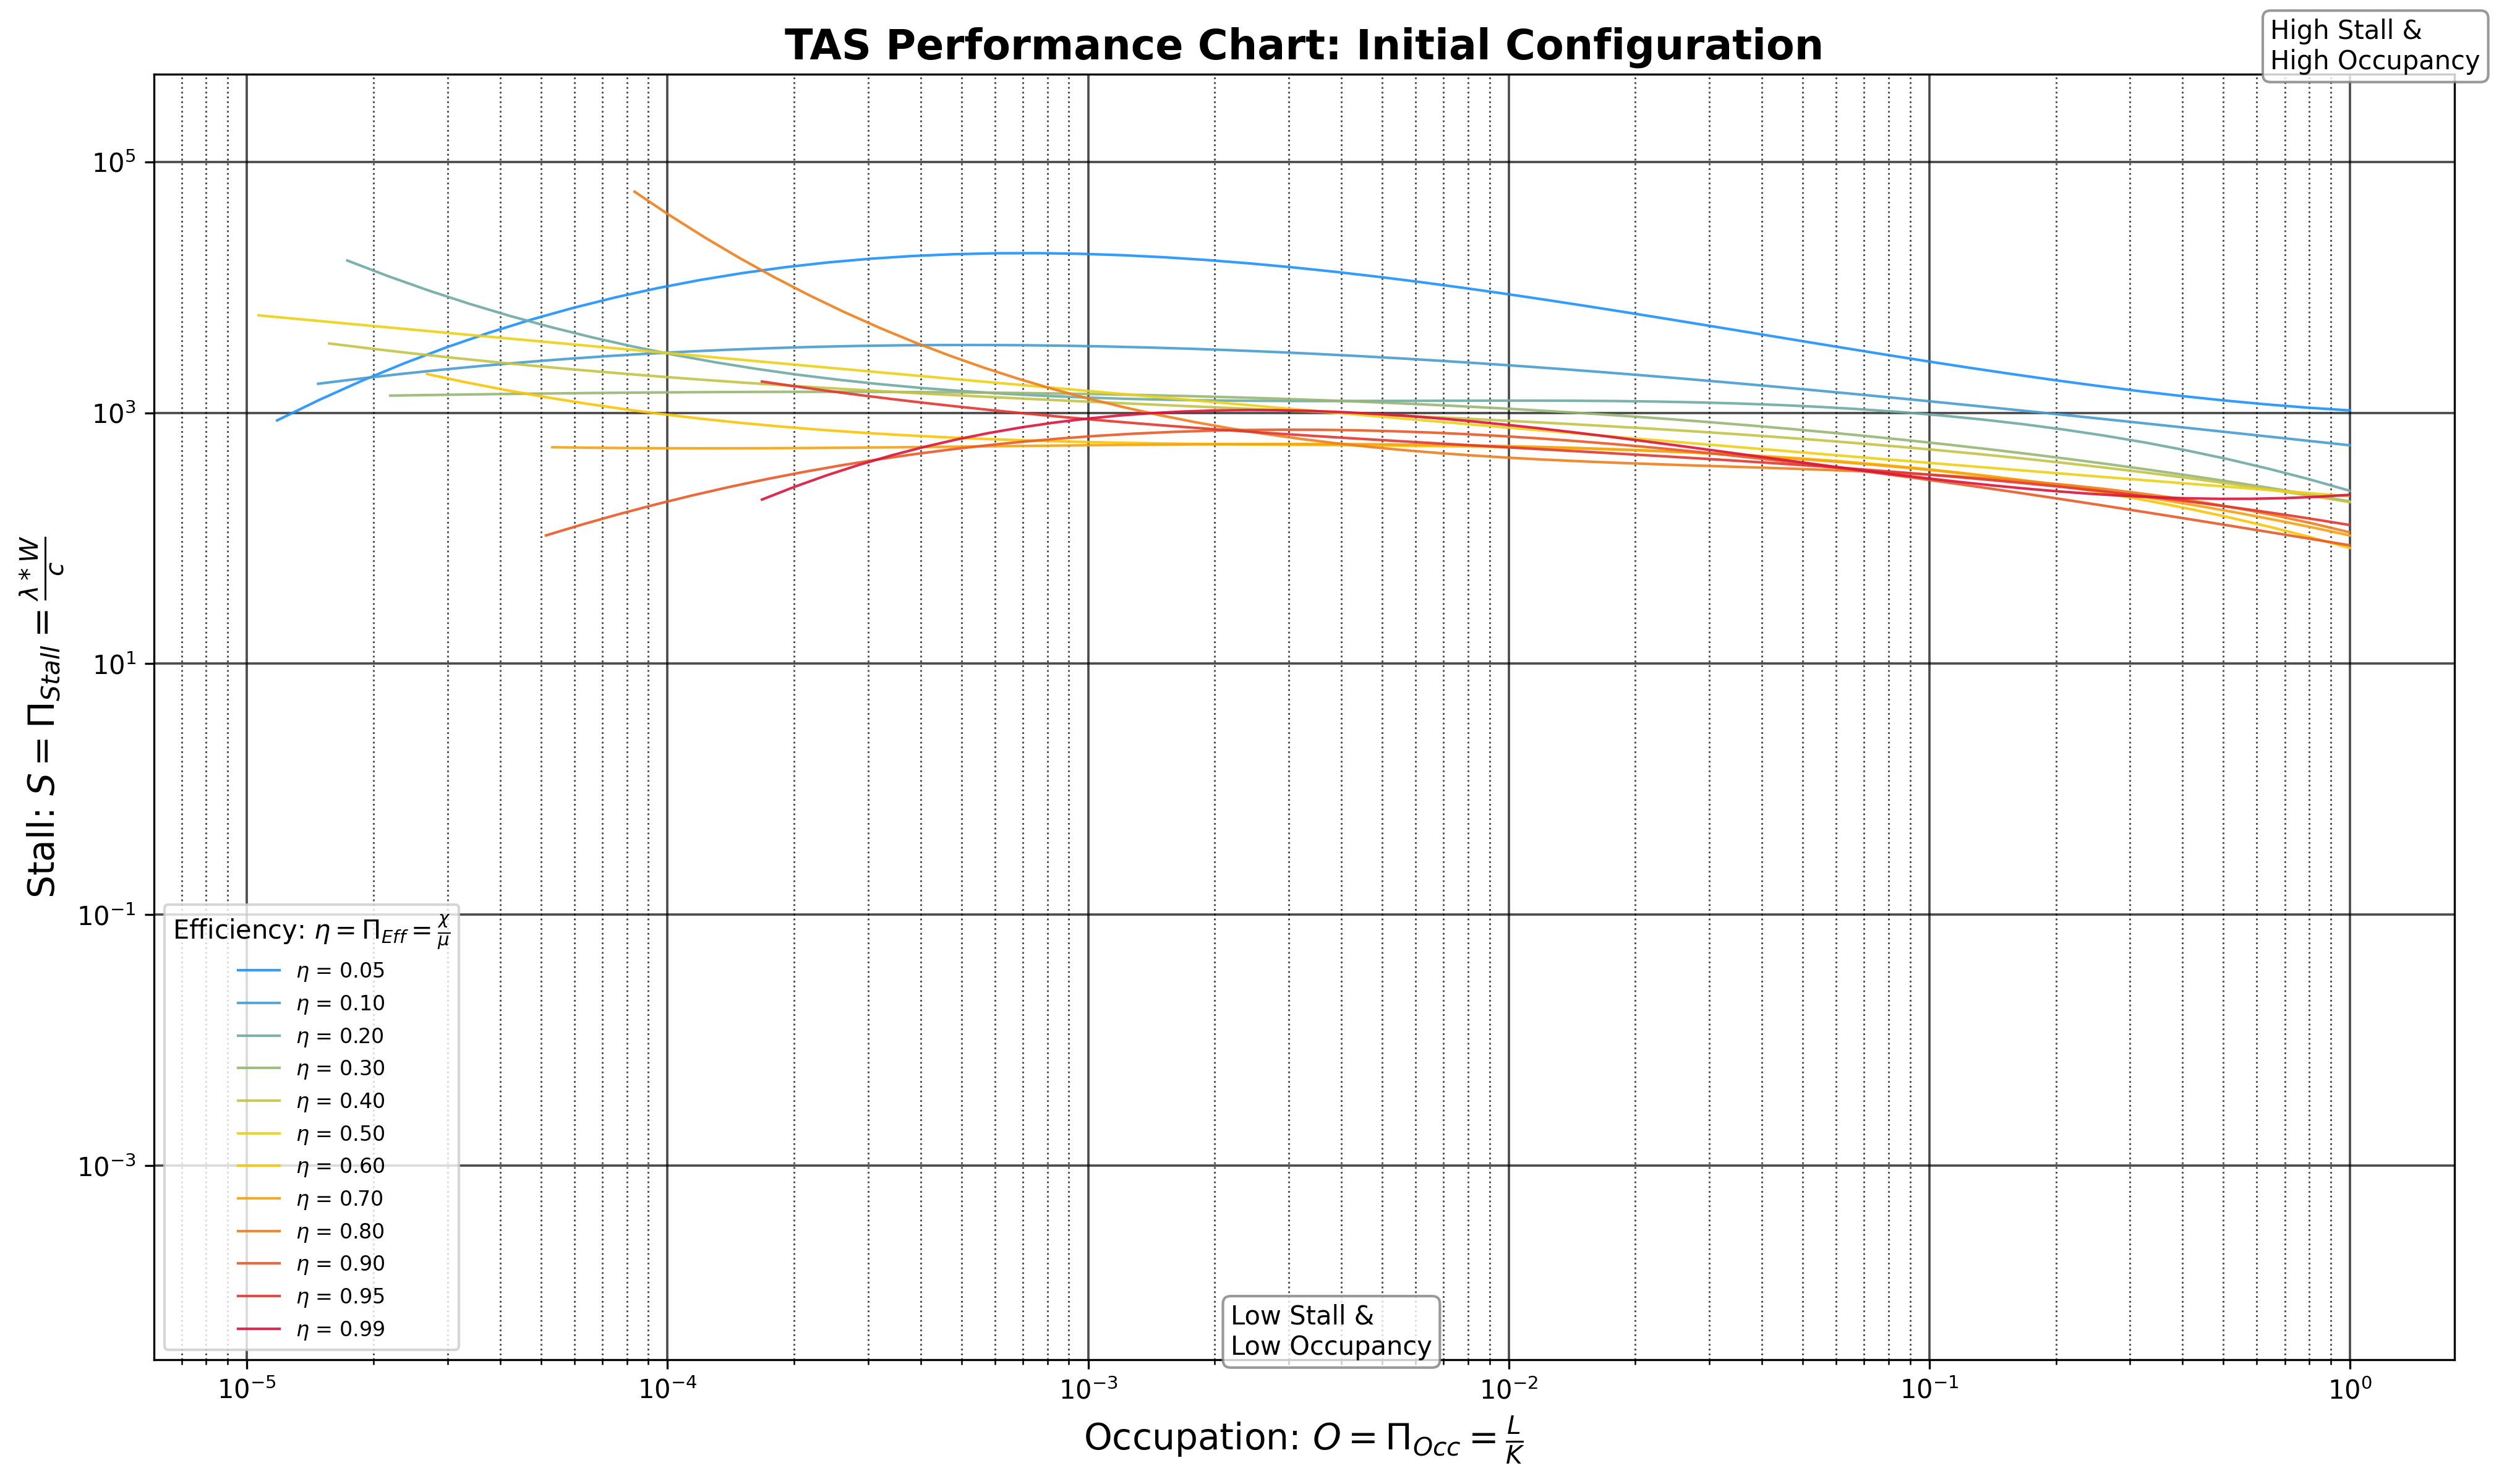

In [51]:
# plotting the queue network dimensionless chart
# selecting images folder
file_path = os.path.join(PATH, results_folder, cs_folder, img_folder)
print(f"Data path: {file_path}")

# plot dimensionless system chart
title = "TAS Performance Chart: Initial Configuration"
plot_performance_coef_chart(plot_df,
                            contour_name,
                            contour_vals,
                            metrics,
                            labels,
                            title,
                            file_path,
                            "dflt_dimensional_perf_chart.png")

In [46]:
# plot this data in regular chart
plot_df.info()
print(plot_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257986 entries, 0 to 257985
Data columns (total 3 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   O=\Pi_{Occ}=\frac{L}{K}            257986 non-null  float64
 1   S=\Pi_{Stall}=\frac{\lambda*W}{c}  257986 non-null  float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}    257986 non-null  float64
dtypes: float64(3)
memory usage: 5.9 MB
       O=\Pi_{Occ}=\frac{L}{K}  S=\Pi_{Stall}=\frac{\lambda*W}{c}  \
count            257986.000000                       2.579860e+05   
mean                  0.151173                       1.166018e+05   
std                   0.207657                       2.494168e+05   
min                   0.000011                       8.412597e-12   
25%                   0.015894                       2.526259e+03   
50%                   0.060328                       3.152782e+04   
75%                   0.195116            

In [47]:
a =

SyntaxError: invalid syntax (905710932.py, line 1)

##### **Optimized Configuration**

In [ ]:
# Load configuration with mixed queue models
file_path = os.path.join(PATH, data_folder, cs_folder)
opti_qn_cfg = load(file_path, "optimal_qn_model.csv")
print("Queue Network Configuration:")
opti_qn_cfg.head()

In [ ]:
# Load configuration with mixed queue models
opti_da_cfg = load(file_path, "optimal_dim_variables.csv")
print("Dimension Variables Configuration:")
opti_da_cfg.head()

###### **Loading Dimensional Variables**

In [ ]:
print("---- Dimensional Variables by Dimensional Matrix ----")
# create a dimensional set of variables from config file
# unique dimensional matrix
opti_dim_relevance_lt = opti_da_cfg["dm"].unique().tolist()
# dictionary to hold dimensional variables
opti_dim_var_groups = {}

# group by dimensional matrix
for dm in opti_dim_relevance_lt:
    # filter by dimensional matrix number
    _vars = opti_da_cfg[opti_da_cfg["dm"] == dm]
    # filter by relevant attributes
    _vars = _vars[_vars["dm"] == dm]
    print(f"Dimensional Matrix: {dm}, with {_vars.shape[0]} relevant vars.")
    tdict = {}
    for var in _vars.to_dict(orient="records"):
        key = var["_sym"]
        # remove unnecessary keys
        var.pop("dm", None)
        # cast internal dict column
        if var.get("_dist_params") != None:
            data = eval(var.get("_dist_params"))
            dt = {"_dist_params": data}
            # print(data, type(data))
            var.update(dt)
        tdict[key] = Variable(**var)
    # add to dictionary
    opti_dim_var_groups[dm] = tdict

print(f"No. of Dimensional Variables Groups: {len(opti_dim_var_groups)}")

In [ ]:
print("---- Configure Simulation Distribution Function for Variables ----")
# im tired so lambda functions are in order
for dm in opti_dim_var_groups:
    for key, var in opti_dim_var_groups[dm].items():
        # print(var)
        # if the distriburion is constant
        if var._dist_type == "constant":
            _constant = var._dist_params.get("constant")
            var._dist_func = lambda: _constant
        # with uniform distribution
        if var._dist_type == "uniform":
            _low = var._dist_params.get("low")
            _high = var._dist_params.get("high")
            var._dist_func = lambda: np.random.uniform(_low, _high)
        # with exponential distribution
        if var._dist_type == "exponential":
            _scale = var._dist_params.get("scale")
            var._dist_func = lambda:  np.random.exponential(_scale)


###### **Creating Dimensional Model**

In [ ]:
print("---- Creating Dimensional Model (Matrix) ----")
opti_dim_model_groups = {}

# group by dimensional matrix
for dm in opti_dim_relevance_lt:
    tas_vars = opti_dim_var_groups[dm]
    print(f"Dimensional Matrix ID: {dm}, N Variables: {len(tas_vars)}")
    opti_dim_model_groups[dm] = DimMatrix(_fwk="SOFTWARE",
                                          _idx=dm,
                                          _framework=tas_scm)
    # setting Dimensional Model variables
    opti_dim_model_groups[dm].variables = tas_vars
    _msg = "\tSetting parameters for the DA, "
    _msg += f"N Variables: {len(opti_dim_model_groups[dm].variables)}. "
    # _msg += f"Variables: {opti_dim_model_groups[dm].variables.keys()}"
    print(_msg)

    # setting Dimensional Model relevance list
    opti_dim_model_groups[dm].relevant_lt = tas_vars
    _msg = "\tSetting the relevance list for the DA, "
    _msg += f"N Variables: {len(opti_dim_model_groups[dm].relevant_lt)}. "
    # _msg += f"Variables: {opti_dim_model_groups[dm].relevant_lt.keys()}"
    print(_msg)


In [ ]:
print("--- Solving Dimensional Model (Matrix) ----")
# solving each dimensional model
for dm in opti_dim_model_groups:
    print(f"Solving Dimensional Model ID: {dm}")
    # Here you would implement the logic to solve the dimensional model
    print(f"\tCreating Matrix for Dimensional Model ID: {dm}")
    opti_dim_model_groups[dm].create_matrix()
    opti_dim_model_groups[dm].solve_matrix()
    n = len(opti_dim_model_groups[dm].coefficients)
    print(f"\tDimensional Model ID: {dm}, N Coefficients: {n}")
    print(f"\tFinished Solving Dimensional Model ID: {dm}")
    # print(len(opti_dim_model_groups[dm].coefficients), "\n")
    # print(opti_dim_model_groups[dm].coefficients, "\n")
    # print(opti_dim_model_groups, "\n")

###### **Calculating Pi-Coefficients**

In [ ]:

print("---- Indexing Coefficients and Sensitivity Groups ----")
# Coefficient Groups
opti_coef_groups = {}
# Sensitivity Groups
opti_sens_groups = {}

for dm in opti_dim_model_groups:
    print(f"Indexing Coefficient Groups from the Dimensional Model ID: {dm}")
    # for pi, coef in opti_dim_model_groups[dm].coefficients.items():
    # creating sensitivity group
    opti_sens_groups[dm] = SensitivityHandler(
        _idx=dm,
        _sym=f"$SA_{{TAS_{dm}}}$",
        name=f"Sensitivity Analysis for TAS DM {dm}",
        description=f"Sensitivity Analysis TAS Dimensional Model ID {dm}.",
        _variables=opti_dim_var_groups[dm],
        _coefficients=opti_dim_model_groups[dm].coefficients,
    )
    # indexing coefficient groups
    keys = opti_dim_model_groups[dm].coefficients.keys()
    values = opti_dim_model_groups[dm].coefficients.values()
    opti_coef_groups[dm] = dict(zip(keys, values))
    n = len(opti_coef_groups[dm])
    print(f"\tIndexed {n} Coefficients for DM ID: {dm}\n")


###### **Running Sensitivity Analysis**

In [ ]:
print("---- Executing Sensitivity Analysis ----")

for dm in opti_sens_groups:
    print(f"Executing Sensitivity Analysis for: {dm}")
    print("\tExecuting Symbolic Analysis...")
    opti_sens_groups[dm].analyze_symbolic(val_type="mean")
    print("\tExecuting Numerical Analysis...")
    opti_sens_groups[dm].analyze_numeric(n_samples=n_sens)
    print(f"Finishing Analysis for: {dm}\n")

In [ ]:
print("---- Sensitivity Analysis Post-Processing ----")
# detailed report
# coefficient global index
i = 0

# sensitivity report statistical data
sens_records = []

# global coefficient name = coefficient formula
pi_coef = {}

for dm in opti_sens_groups:
    print(f"Sensitivity Report for Dimensional Model ID: {dm}")
    n = len(opti_sens_groups[dm].results)
    print(f"\tSensitivity Reports Size: {n}")
    # for key, val in opti_sens_groups[dm].results.items():
    #     print(f"\t{key}: {val}")
    print(f"\tEnding Sensitivity report No. {dm}\n")

# creating DataFrame from records
opti_node_sens = pd.DataFrame(sens_records)


###### **Running Monte Carlo Simulation**

In [ ]:
print("---- Create Monte Carlo Simulations ----")
opti_mc_groups = {}

for dm in opti_dim_model_groups:
    print(f"Indexing Coefficient Groups from the Dimensional Model ID: {dm}")
    # for pi, coef in opti_dim_model_groups[dm].coefficients.items():
    # creating sensitivity group
    opti_mc_groups[dm] = MonteCarloHandler(
        _idx=dm,
        _fwk="SOFTWARE",
        _sym=f"$MC_{{TAS_{dm}}}$",
        name=f"Monte Carlo Simulation for TAS DM {dm}",
        description=f"Monte Carlo Simulation TAS Dimensional Model ID {dm}.",
        _variables=opti_dim_model_groups[dm]._relevant_lt,
        _coefficients=opti_dim_model_groups[dm].coefficients,
    )
    n = len(opti_mc_groups[dm].coefficients)
    print(f"\tIndexed {n} Coefficients Monte Carlo: {dm}\n")

In [ ]:
print("---- Execute Monte Carlo Simulations ----")
for dm in opti_mc_groups:
    print(f"\tStarting Montecarlo Simulation group: {dm}")
    opti_mc_groups[dm]._create_distributions()
    opti_mc_groups[dm]._create_simulations()
    opti_mc_groups[dm].simulate(n_samples=n_exp)
    print(f"\tFinishing simulation for group: {dm}\n")

###### **Plotting Dimensional Model Chart**

In [ ]:
print("---- Monte Carlo Simulation Post-Processing (Exp + Stats) ----")
# detailed report
# coefficient global index
i = 0

# data for unified dataframes
exp_records = {}

# simulation statistical data
stats_records = []

# global coefficient name = coefficient formula
pi_coef = {}

# iterate over monte carlo groups
for mcg in opti_mc_groups:
    # monte carlo group header
    n = opti_mc_groups[mcg]._iterations
    _msg = f"\tMonte Carlo Simulation Group: {mcg}, with {n} samples."
    print(_msg)
    _vars = opti_mc_groups[mcg].variables.keys()
    # _vars = ", ".join(v for v in _vars)
    _msg = f"\tN Variables: {len(_vars)}, Var := {list(_vars)}"
    print(_msg)

    _coefs = opti_mc_groups[mcg].coefficients
    print(f"\tNo. of Pi-Coefficients in the group: {len(_coefs)}")
    # iterating the Pi names of the group coefficients
    for j, pi in enumerate(_coefs):
        # getting the coefficient data
        coef = _coefs[pi]
        # coefficient header
        # getting the coefficient relevant dimensional variables
        cvars = list(coef.var_dims.keys())
        # print(f"\t\tCoefficient: {coef.name}: {pi} = {coef.pi_expr}")
        # print(f"\t\t\tGlobal Idx: {i}, Inputs := {cvars}, Size: {len(cvars)}")

        # rename Pi for DataFrame column with global idx
        pi_rename = str(pi)
        pi_rename = pi_rename.replace(str(j), str(i))
        # print(f"\t\t\tRenaming Coef. FROM: {pi} TO: {pi_rename}")
        pi_coef[pi_rename] = coef.pi_expr

        # get simulation results
        simulations = opti_mc_groups[mcg].get_simulation(pi)
        # print(type(simulations))
        if simulations:
            # exporting results
            results = simulations.extract_results()
            # print(f"\t\t\tResults keys: {list(results.keys())}")
            for key in results:
                new_key = key.replace(pi, pi_rename)
                # dictionary[new_key] = dictionary.pop(old_key)
                results[new_key] = results.pop(key)
            # print(f"\t\t\tResults keys: {list(results.keys())}")
            
            exp_records.update(results)

            # exporting statistics
            stats = {
                "name": pi_rename,
                "coef": coef.pi_expr
            }
            # print(f"\t\t\tStatistics before update: {stats}")
            stats.update(simulations.statistics)
            # print(f"\t\t\tStatistics after update: {stats}")
            stats_records.append(stats)

        # incrementing global index
        i += 1
        # print(i)
    print(f"\tEnding Monte Carlo group No.: {mcg}...\n")

# creating DataFrame from records
opti_mc_exp = pd.DataFrame(exp_records)
opti_mc_stats = pd.DataFrame(stats_records)

In [ ]:
print("\n--- Monte Carlo Simulation Experiment Results ---")
# print(opti_analyt_nd_metrics)

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_node_exp.csv", opti_mc_exp)

print(opti_mc_exp.shape)
opti_mc_exp.info()
opti_mc_exp.head()

In [ ]:
print("\n--- Monte Carlo Simulation Statistics ---")

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_node_stats.csv", opti_mc_stats)

print(opti_mc_stats.shape)
opti_mc_stats.info()
opti_mc_stats.head()

In [ ]:
print("---- Pi-Coefficients DataFrame ----")
# Extracting just the coefficients from the experimental DataFrame
pi_keys = list(pi_coef.keys())
print(f"Total No. of Pi-Coefficients: {len(pi_keys)}")
opti_pi_coefs = pd.DataFrame(opti_mc_exp[pi_keys])
pi_cols = {}
# renaming columns with coef = formula
for k, v in pi_coef.items():
    pi_cols[k] = f"{k}={v}"
# renaming columns
opti_pi_coefs.rename(columns=pi_cols, inplace=True)

In [ ]:
print("\n--- Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_node_coeffs.csv", opti_pi_coefs)

# checking the Pi DataFrame
print(opti_pi_coefs.shape)
opti_pi_coefs.info()
opti_pi_coefs.head()

In [ ]:
# make generic columns for dimensionless coefficients
sys_name = "TAS"
sys_cols = [re.sub(r"\d+", sys_name, col) for col in pi_coef.values()]
# removing redundant entries, keeping order
sys_cols = list(dict.fromkeys(sys_cols))
for i in range(len(sys_cols)):
    formula = sys_cols[i]
    sys_cols[i] = f"\\Pi_{{{i+1}}}={formula}"
print(f"System generic columns: {len(sys_cols)}, {sys_cols}")

In [ ]:
print("---- Post-Processing System Pi-Coefficients ----")
print(f"Pi-Coeffishients shape: {opti_pi_coefs.shape}")
# dictionary for system records
sys_records = {}

# iterate over the generic columns
for i, col in enumerate(sys_cols):
    print(f"\tSetting column: {col} in idx {i}")
    # mod = i % len(sys_cols)
    # print(f"\tidx: {col}, Sys Col: {col}, Module: {mod}")
    # iterate over the pi dataframe columns
    for j in range(i, opti_pi_coefs.shape[1], len(sys_cols)):
        c = opti_pi_coefs.columns[j]
        data = opti_pi_coefs[c].values
        # print(f"\t\textracting data for column: {c}, size: {len(data)}")
        if col not in sys_records:
            # print(f"\t\tCreating new column: {col}!!!...")
            sys_records[col] = data
            # break
        elif col in sys_records:
            # print(f"\t\tAppending data to existing column: {col}")
            sys_records[col] = np.concatenate((sys_records[col], data))
            # break
    print(f"\tFinished column: {col} in idx {i}\n")

In [ ]:
print("---- Checking System Records Info ----")
for k, v in sys_records.items():
    print(f"{k}: {len(v)}")
    
print("---- System DataFrame ----")
opti_sys_coef = pd.DataFrame(sys_records)
print(opti_sys_coef.shape)
opti_sys_coef.info()
opti_sys_coef.head()

In [ ]:
# creating derived Pi-Coefficients
print("---- Creating Derived Pi-Coefficients ----")
# derived coefficients columns
# defining plot colums
plot_cols = []

# working variables for derived coefficients
print("Creating Pi-Coefficient from: \\Pi_{{4}}, \\Pi_{{5}}")
# Pi_4 = c / K
temp = f"\\Pi_{{4}}=\\frac{{c_{{{sys_name}}}}}{{K_{{{sys_name}}}}}"
pi_4 = opti_sys_coef[temp]

# Pi_5 = L / K
temp = f"\\Pi_{{5}}=\\frac{{L_{{{sys_name}}}}}{{K_{{{sys_name}}}}}"
pi_5 = opti_sys_coef[temp]

# 2 --->> Queue Occupancy Coef: Pi_7 = Pi_5 * Pi_4^{-1}
print("Creating System Obstruction Coefficient: \\Pi_{{7}}")
numerator = f"L_{{{sys_name}}}"
denominator = f"C_{{{sys_name}}}"

# Occupation Coefficient: Pi_6 = L / C
new_coef = f"\\Pi_{{Occ}}=\\frac{{{numerator}}}{{{denominator}}}"
opti_sys_coef[new_coef] = pi_5 * (pi_4**-1)
# adding to plot coefficients for later
plot_cols.append(new_coef)

# working variables for derived coefficients
print("Creating Pi-Coefficients from: \\Pi_{{1}}, \\Pi_{{2}}, \\Pi_{{3}}")

# Pi_1 = lambda * W
temp = f"\\Pi_{{1}}=\\lambda_{{{sys_name}}}*W_{{{sys_name}}}"
pi_1 = opti_sys_coef[temp]

# Pi_2 = chi / lambda
temp = f"\\Pi_{{2}}=\\frac{{\\chi_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_2 = opti_sys_coef[temp]

# Pi_3 = mu / lambda
temp = f"\\Pi_{{3}}=\\frac{{\\mu_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_3 = opti_sys_coef[temp]

# 1 --->> System/Component Congestion Coef: Pi_7 = Pi_2 * Pi_3^{-1} * Pi_1
print("Creating System Congestion Coefficient: \\Pi_{{7}}")
numerator = f"\\chi_{{{sys_name}}}*\\lambda_{{{sys_name}}}*W_{{{sys_name}}}"
denominator = f"\\mu_{{{sys_name}}}"

# Stall Coefficient Pi_7 = chi * Lambda * W / mu
new_coef = f"\\Pi_{{Stall}}=\\frac{{{numerator}}}{{{denominator}}}"
opti_sys_coef[new_coef] = pi_2 * (pi_3**-1) * pi_1
# adding to plot coefficients for later
plot_cols.append(new_coef)

# adding utilization to the dataframe, rho = Pi_3^{-1}
print("Creating Pi-Coefficient from :\\Pi_{{3}}")
# new_coef = f"\\rho_{{{sys_name}}}=\\frac{{\\lambda_{{{sys_name}}}}}{{\\mu_{{{sys_name}}}}}"
new_coef = f"\\rho"
# new_coef = "\\Pi_{{3}}^{-1}"
# new_coef += "=\\frac{1}{\\Pi_{{3}}}"
new_coef += f"=\\frac{{\\lambda_{{{sys_name}}}}}{{\\mu_{{{sys_name}}}}}"
# simp_coef = "$\\rho$"
opti_sys_coef[new_coef] = pi_3**-1
# adding to plot coefficients for later
plot_cols.append(new_coef)

In [ ]:
print("\n--- System Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH, results_folder, cs_folder, data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_net_coeffs.csv", opti_pi_coefs)
opti_sys_coef.info()
opti_sys_coef.head()

In [ ]:
print("--- Charting Occupation and Congestion Coefficients ---")

# defining the contour lines
contour_vals = [
    # 0.05,   # 0
    0.1,    # 1
    0.2,    # 2
    0.3,    # 3
    0.4,    # 4
    0.5,    # 5
    0.6,    # 6
    # 0.65,   # 7
    0.7,    # 8
    0.8,    # 9
    0.9,    # 10
    # 0.95,   # 11
    # 0.99,   # 12
    1.0,    # 13
    1.2,    # 14
    1.5,    # 15
    2.0,    # 16
    3.0,    # 17
]

# 
plot_df = pd.DataFrame(opti_sys_coef[plot_cols])
metrics = plot_df.columns.tolist()
labels = [
    "Occupation",
    "Congestion",
    "Utilization",
]
contour_name = plot_cols[-1]
print(f"Contour levels from: {contour_name}")
print(f"No. of contour line {len(contour_vals)}")
plot_df.info()

In [ ]:
# plotting the queue network dimensionless chart
# selecting images folder
file_path = os.path.join(PATH, results_folder, cs_folder, img_folder)
print(f"Data path: {file_path}")

# plot dimensionless system chart
title = "TAS Performance Coefficients: After Adaptation."
plot_performance_coef_chart(plot_df,
                            contour_name,
                            contour_vals,
                            metrics,
                            labels,
                            title,
                            file_path,
                            "opti_dimensional_perf_chart.png")

#### **Solving Dimensional Model**

##### **Base Configuration**

In [ ]:
# extract parameters from the configuration DataFrame
# and casting them to proper types
nodes = list(dflt_qn_cfg["node"].values.astype(int))
names = list(dflt_qn_cfg["name"].values)
types = list(dflt_qn_cfg["type"].values)
mius = list(dflt_qn_cfg["miu"].values)
lambda_zs = list(dflt_qn_cfg["lambda0"].values)
n_servers = list(dflt_qn_cfg["s"].values.astype(int))
kaps = list(dflt_qn_cfg["K"].values.astype(float))

# Convert K=0=nan to understandable infinite capacity -> None
for i in range(len(kaps)):
    if np.isnan(kaps[i]):
        kaps[i] = None
    else:
        kaps[i] = float(kaps[i])

# Convert string representations of arrays to actual numpy arrays
# and create routing matrix P
prob = []
for pm_str in dflt_qn_cfg["pm"].values:
    pm_values = pm_str.strip("[]").split(",")
    pm_values = [float(val) for val in pm_values]
    prob.append(pm_values)
P = np.array((prob))

# create queue objects based on the configuration
queues = []
for i in range(len(mius)):
    # print(f"Creating queue: '{names[i]}' for Node: {nodes[i]}")
    # print(f"  Type: {types[i]}, λ: {lambda_zs[i]}, μ: {mius[i]}, s: {n_servers[i]}, K: {kaps[i]}")
    # create queue object
    q = Queue(
        model=types[i],
        _lambda=lambda_zs[i],
        miu=mius[i],
        n_servers=n_servers[i],
        kapacity=kaps[i],
    )
    # add queue to the list
    queues.append(q)

In [ ]:
# Solve the network analytically
# first node metrics
dflt_analyt_nd_metrics = solve_jackson_network(mius, lambda_zs, queues, P)

# then network metrics
dflt_analyt_net_metrics = calculate_net_metrics(dflt_analyt_nd_metrics)
dflt_analyt_net_metrics["nodes"] = len(list(dflt_analyt_nd_metrics["node"]))

##### **Optimized Configuration**

#### **Data Analysis**

The steps are:

1) Extract and organize simulation data into a unique DataFrame.
2) Add metadata and basic statistics.
3) Save the dataframe to a CSV file.
4) Create a basic dimensionless plot (similar to Moody's chart)

##### **Data Post-Processing**


##### **Optimized Configuration**

#### **Numerical Solution (Simulation-Based)**

##### **Base Configuration**

##### **Optimized Configuration**

## **Results**

### **Compare Results**

### **Saving Results**

## **Analysis**

### **Graph Analysis**

In [ ]:
# Create directories if they dont exist
os.makedirs("data/CS-1-HealthTAS/img", exist_ok=True)

# Figure setup with appropriate size, resolution and white background
fig, ax = plt.subplots(figsize=(12, 9), dpi=300, facecolor="white")
ax.set_facecolor("white")

# Get first two coefficients for the plot axes
pi_list = list(tas_mch._coefficients.keys())
pi_x = pi_list[0]  # / pi_list[3]  # first/Third coefficient for x-axis
pi_x1 = pi_list[3]               # First coefficient for x-axis
pi_y = pi_list[1]               # Second coefficient for y-axis

# Calculate utilization ratio (common in queueing theory)
df_results["utilization"] = 1 / df_results["\\Pi_{2}"]

# Group data by utilization ratio to create characteristic curves
utilization_ranges = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
colors = plt.cm.viridis(np.linspace(0, 1, len(utilization_ranges)))

# Add hexbin background to show data density (like Moody chart)
hb = plt.hexbin(
    df_results[pi_x],
    df_results[pi_y],
    gridsize=40,
    cmap="Blues",
    alpha=0.10,
    mincnt=1
)

# Plot characteristic curves for different utilization ranges
for i, util in enumerate(utilization_ranges):
    # Filter data near this utilization value
    mask = (df_results["utilization"] >= util - 0.05) & \
           (df_results["utilization"] <= util + 0.05)
    subset = df_results[mask]

    if len(subset) > 10:  # Only draw if we have enough points
        # Sort by x-value for smooth curves
        subset = subset.sort_values(by=pi_x)

        # Create a polynomial fit (3rd degree works well for most curves)
        if len(subset) > 5:
            z = np.polyfit(np.log10(subset[pi_x]), np.log10(subset[pi_y]), 3)
            p = np.poly1d(z)

            # Create smooth x values for the line
            x_smooth = np.logspace(
                np.log10(subset[pi_x].min()),
                np.log10(subset[pi_x].max()),
                100
            )

            # Calculate predicted y values (convert back from log space)
            y_smooth = 10**p(np.log10(x_smooth))

            # Plot the trend line
            plt.plot(
                x_smooth,
                y_smooth,
                "-",
                linewidth=2,
                color=colors[i],
                label=f"ρ = {util:.1f}"
            )

# # Add contour lines for queue length
# queue_length_values = [1e-3, 1e-2, 1e-1, 1.0, 1e1, 1e2, 1e3]
# # [10, 20, 30, 40, 50]
# # [1e-3, 1e-2, 1e-1, 1.0, 1e1, 1e2, 1e3]
# contour = plt.tricontour(
#     df_results[pi_x1],
#     df_results[pi_y],
#     # df_results["\\Pi_{3}"],
#     # df_results["n_{1}_\\Pi_{0}"],
#     df_results["L_{1}_\\Pi_{3}"],
#     # df_results[pi_x] / df_results[pi_x1],
#     levels=queue_length_values,
#     colors="black",
#     linestyles="dashed",
#     linewidths=0.5,
#     alpha=0.75
# )

# # Add contour labels in black
# plt.clabel(contour, inline=True, fontsize=10, fmt="n=%4.0f", colors="black")

# Set up log scales (standard for Moody-like charts)
plt.xscale("log")
plt.yscale("log")

# Add grid with minor lines - lighter color for better visibility on white background
plt.grid(True, which="both", ls="-", color="lightgray", alpha=0.75)
plt.grid(True, which="minor", ls=":", color="lightgray", alpha=0.75)
plt.minorticks_on()

# Format tick labels for better readability
formatter = ticker.LogFormatterMathtext(base=10)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Make sure ticks and labels are black
ax.tick_params(axis="both", colors="black")

# Add descriptive labels and title in black
plt.xlabel(
    f"${pi_x}$ = ${tas_mch._coefficients[pi_x].pi_expr}$", fontsize=14, color="black")
plt.ylabel(
    f"${pi_y}$ = ${tas_mch._coefficients[pi_y].pi_expr}$", fontsize=14, color="black")
plt.title("Queue System Performance Chart", fontsize=16, color="black")

# Add legend with clear styling
legend = plt.legend(
    title="System Utilization ($\\rho$)",
    loc="best",
    fontsize=12,
    framealpha=0.9
)
legend.get_title().set_color("black")

# Add annotations for regions with better visibility on white background
plt.text(
    df_results[pi_x].min()*1.5,
    df_results[pi_y].max()*0.8,
    "Low Utilization\nRegion",
    fontsize=12,
    ha="left",
    color="black",
    bbox=dict(facecolor="white", alpha=0.95,
              boxstyle="round", edgecolor="gray")
)

plt.text(
    df_results[pi_x].max()*0.5,
    df_results[pi_y].min()*1.5,
    "High Utilization\nRegion",
    fontsize=12,
    ha="right",
    color="black",
    bbox=dict(facecolor="white", alpha=0.95,
              boxstyle="round", edgecolor="gray")
)

# Save and display with white background
plt.tight_layout()
plt.savefig("data/CS-1-HealthTAS/img/tas_behaviour_chart.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## **Conclusion**

Understanding Contour Behavior in Your Queue System Chart
The contour lines in your plot represent queue length values (10, 20, 30, 40, 50), and they appear higher and closer to the Y-axis for higher values due to several important queue theory principles:

Why This Pattern Occurs
Exponential Queue Growth: In queueing theory, as system utilization (ρ = λ/μ) approaches 1.0, queue length grows exponentially rather than linearly. This fundamental property creates the compressed contour pattern you're seeing.

Dimensionless Variables Relationship: Your dimensionless plot shows that:

Small changes in the X-axis variable (first Pi coefficient) cause large changes in queue length when the system is near capacity
The Y-axis variable (second Pi coefficient) has less impact on queue length at higher utilization levels
Log-Log Scale Effect: You're using logarithmic scales on both axes, which compresses the higher values and spreads out the lower values, making this pattern more pronounced.

Queue Theory Interpretation
This pattern visualizes a critical queueing system concept: the performance cliff effect. As your system approaches saturation:

Small increases in load (moving right on X-axis) cause dramatically larger queue lengths
Improving service rate (moving up on Y-axis) provides diminishing returns once the system is near saturation
This is why the higher contour lines (40, 50) are compressed toward the right side of the chart and appear to "stack up" near the Y-axis.

Engineering Significance
This pattern in your data suggests:

Your system has a critical utilization threshold beyond which performance degrades rapidly
The "High Utilization Region" you've marked represents the danger zone where small load increases cause large queue growth
The system should be operated with sufficient margin from this threshold to maintain stable performance
This is exactly the kind of relationship a Moody-style chart should reveal - helping identify safe operating regions and performance boundaries in your system.

## **Future Work**

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **HASTA AKI!!!**